In [37]:
import mdtraj as md
import os
import glob
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [38]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles'
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [39]:
def extract_ensemble(output_path, pdb_id):
    loss_csv=os.path.join(output_path, pdb_id, 'saved_structures.csv')
    loss_pd=pd.read_csv(loss_csv)
    loss_pd=loss_pd[~loss_pd['full_path'].str.contains('best')]
    loss_pd=loss_pd.sort_values(by='loss').reset_index(drop=True).head(50)
    return loss_pd

In [40]:
df=extract_ensemble(output_path,'1AEL-12_A')

In [41]:
df

,pdb_filename,loss,full_path
0,1AEL-12_A_iter_0406.pdb,0.024899,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
1,1AEL-12_A_iter_0359.pdb,0.034293,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
2,1AEL-12_A_iter_0478.pdb,0.034509,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
3,1AEL-12_A_iter_0446.pdb,0.035554,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
4,1AEL-12_A_iter_0498.pdb,0.035625,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
5,1AEL-12_A_iter_0486.pdb,0.036137,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
6,1AEL-12_A_iter_0440.pdb,0.036215,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
7,1AEL-12_A_iter_0460.pdb,0.036710,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
8,1AEL-12_A_iter_0491.pdb,0.036866,/global/cfs/cdirs/m4704/100125_Nature_Com_data...
9,1AEL-12_A_iter_0445.pdb,0.037364,/global/cfs/cdirs/m4704/100125_Nature_Com_data...


In [42]:
import mdtraj as md
import numpy as np

def generate_rmsd_pairwise_optimized(pdb_id, output_path):
    # 1. Get the file list
    generated_pdb_df = extract_ensemble(output_path, pdb_id)
    all_paths = generated_pdb_df['full_path'].tolist()
    
    if not all_paths:
        return []

    # 2. IO OPTIMIZATION: Load all PDBs at once into a single trajectory
    # This reduces file reads from N*N to just 1 bulk read.
    # Note: This assumes all PDBs for one ID have the same topology (atom count).
    traj = md.load(all_paths)
    
    # 3. Pre-select CA atoms once
    ca_indices = traj.topology.select('name CA')
    
    results = []
    n_frames = traj.n_frames

    # 4. CALCULATION OPTIMIZATION: Vectorized RMSD
    for i in range(n_frames):
        # Compare frame 'i' against the ENTIRE stack of frames in one step
        # This runs in C-optimized code, not Python loops
        rmsd_frame = md.rmsd(traj, traj, frame=i, atom_indices=ca_indices)
        
        # Convert to Angstroms
        rmsd_frame = rmsd_frame * 10
        
        # 5. Remove the self-comparison (value at index i, which is 0.0)
        # to match your original logic of "if index_ref == index: continue"
        rmsd_filtered = np.delete(rmsd_frame, i)
        
        # Add to results
        results.extend(rmsd_filtered)
        
    return results

In [43]:
import pandas as pd
import numpy as np
from joblib import Parallel, delayed

# --- Helper Function for a single row ---
def process_single_protein(pdb_id, output_path):
    # Run the optimized RMSD calculation
    results = generate_rmsd_pairwise_optimized(pdb_id, output_path)
    
    if not results:
        return None

    # Calculate stats immediately to save memory
    row = {
        'protein_id': pdb_id,
        'pair_rmsd_avg': np.mean(results),
        'pair_rmsd_best': np.min(results),
        # You can add the raw results here if you need them stored
        'raw_results': results 
    }
    return row

# --- Main Execution Block ---
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/ensemble_generated/ensembles'
pdb_list=[ f[:-4] for f in os.listdir(ref_path) if f.endswith('.pdb')]

# Run in parallel (n_jobs=-1 uses all available CPU cores)
processed_data = Parallel(n_jobs=-1)(
    delayed(process_single_protein)(i, output_path) for i in pdb_list
)

# Filter out None values (failed cases)
processed_data = [x for x in processed_data if x is not None]

# --- Saving the Data ---

# 1. Create DataFrame
df = pd.DataFrame(processed_data)

# 2. Separate Raw Results (for JSON) and Summary (for CSV)
# Drop the raw list from the main dataframe to keep the CSV clean
summary_df = df.drop(columns=['raw_results'])
raw_results_dict = dict(zip(df['protein_id'], df['raw_results']))

# 3. Save
summary_df.to_csv('protein_rmsd_summary.csv', index=False)
pd.Series(raw_results_dict).to_json('protein_rmsd_details.json')

print("Processing complete and saved.")

Processing complete and saved.


In [44]:
summary_df.sort_values(by='pair_rmsd_avg')

,protein_id,pair_rmsd_avg,pair_rmsd_best
0,2K8R-1_A,0.496139,0.324884
21,1UR6-4_A,0.522801,0.358825
13,1CZ2-8_A,0.524122,0.338592
75,1LMZ-9_A,0.547398,0.367595
4,1P7M-18_A,0.551322,0.375153
...,...,...,...
43,1JFK_A,5.450941,1.206802
31,1JFJ-3_A,6.156148,1.250146
48,1FMF-4_A,6.744115,2.751462
27,1MO7-3_A,10.636987,5.920478


In [45]:
average_vs_ground_truth=pd.read_csv("ensemble_average.csv",index_col=0)

In [46]:
plot_full=average_vs_ground_truth.merge(summary_df,on='protein_id')

In [47]:
import seaborn as sns

/tmp/ipykernel_1602209/1182573383.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(data=plot_full, x='rmsd_avg',y='pair_rmsd_avg',palette='magma',legend=None)


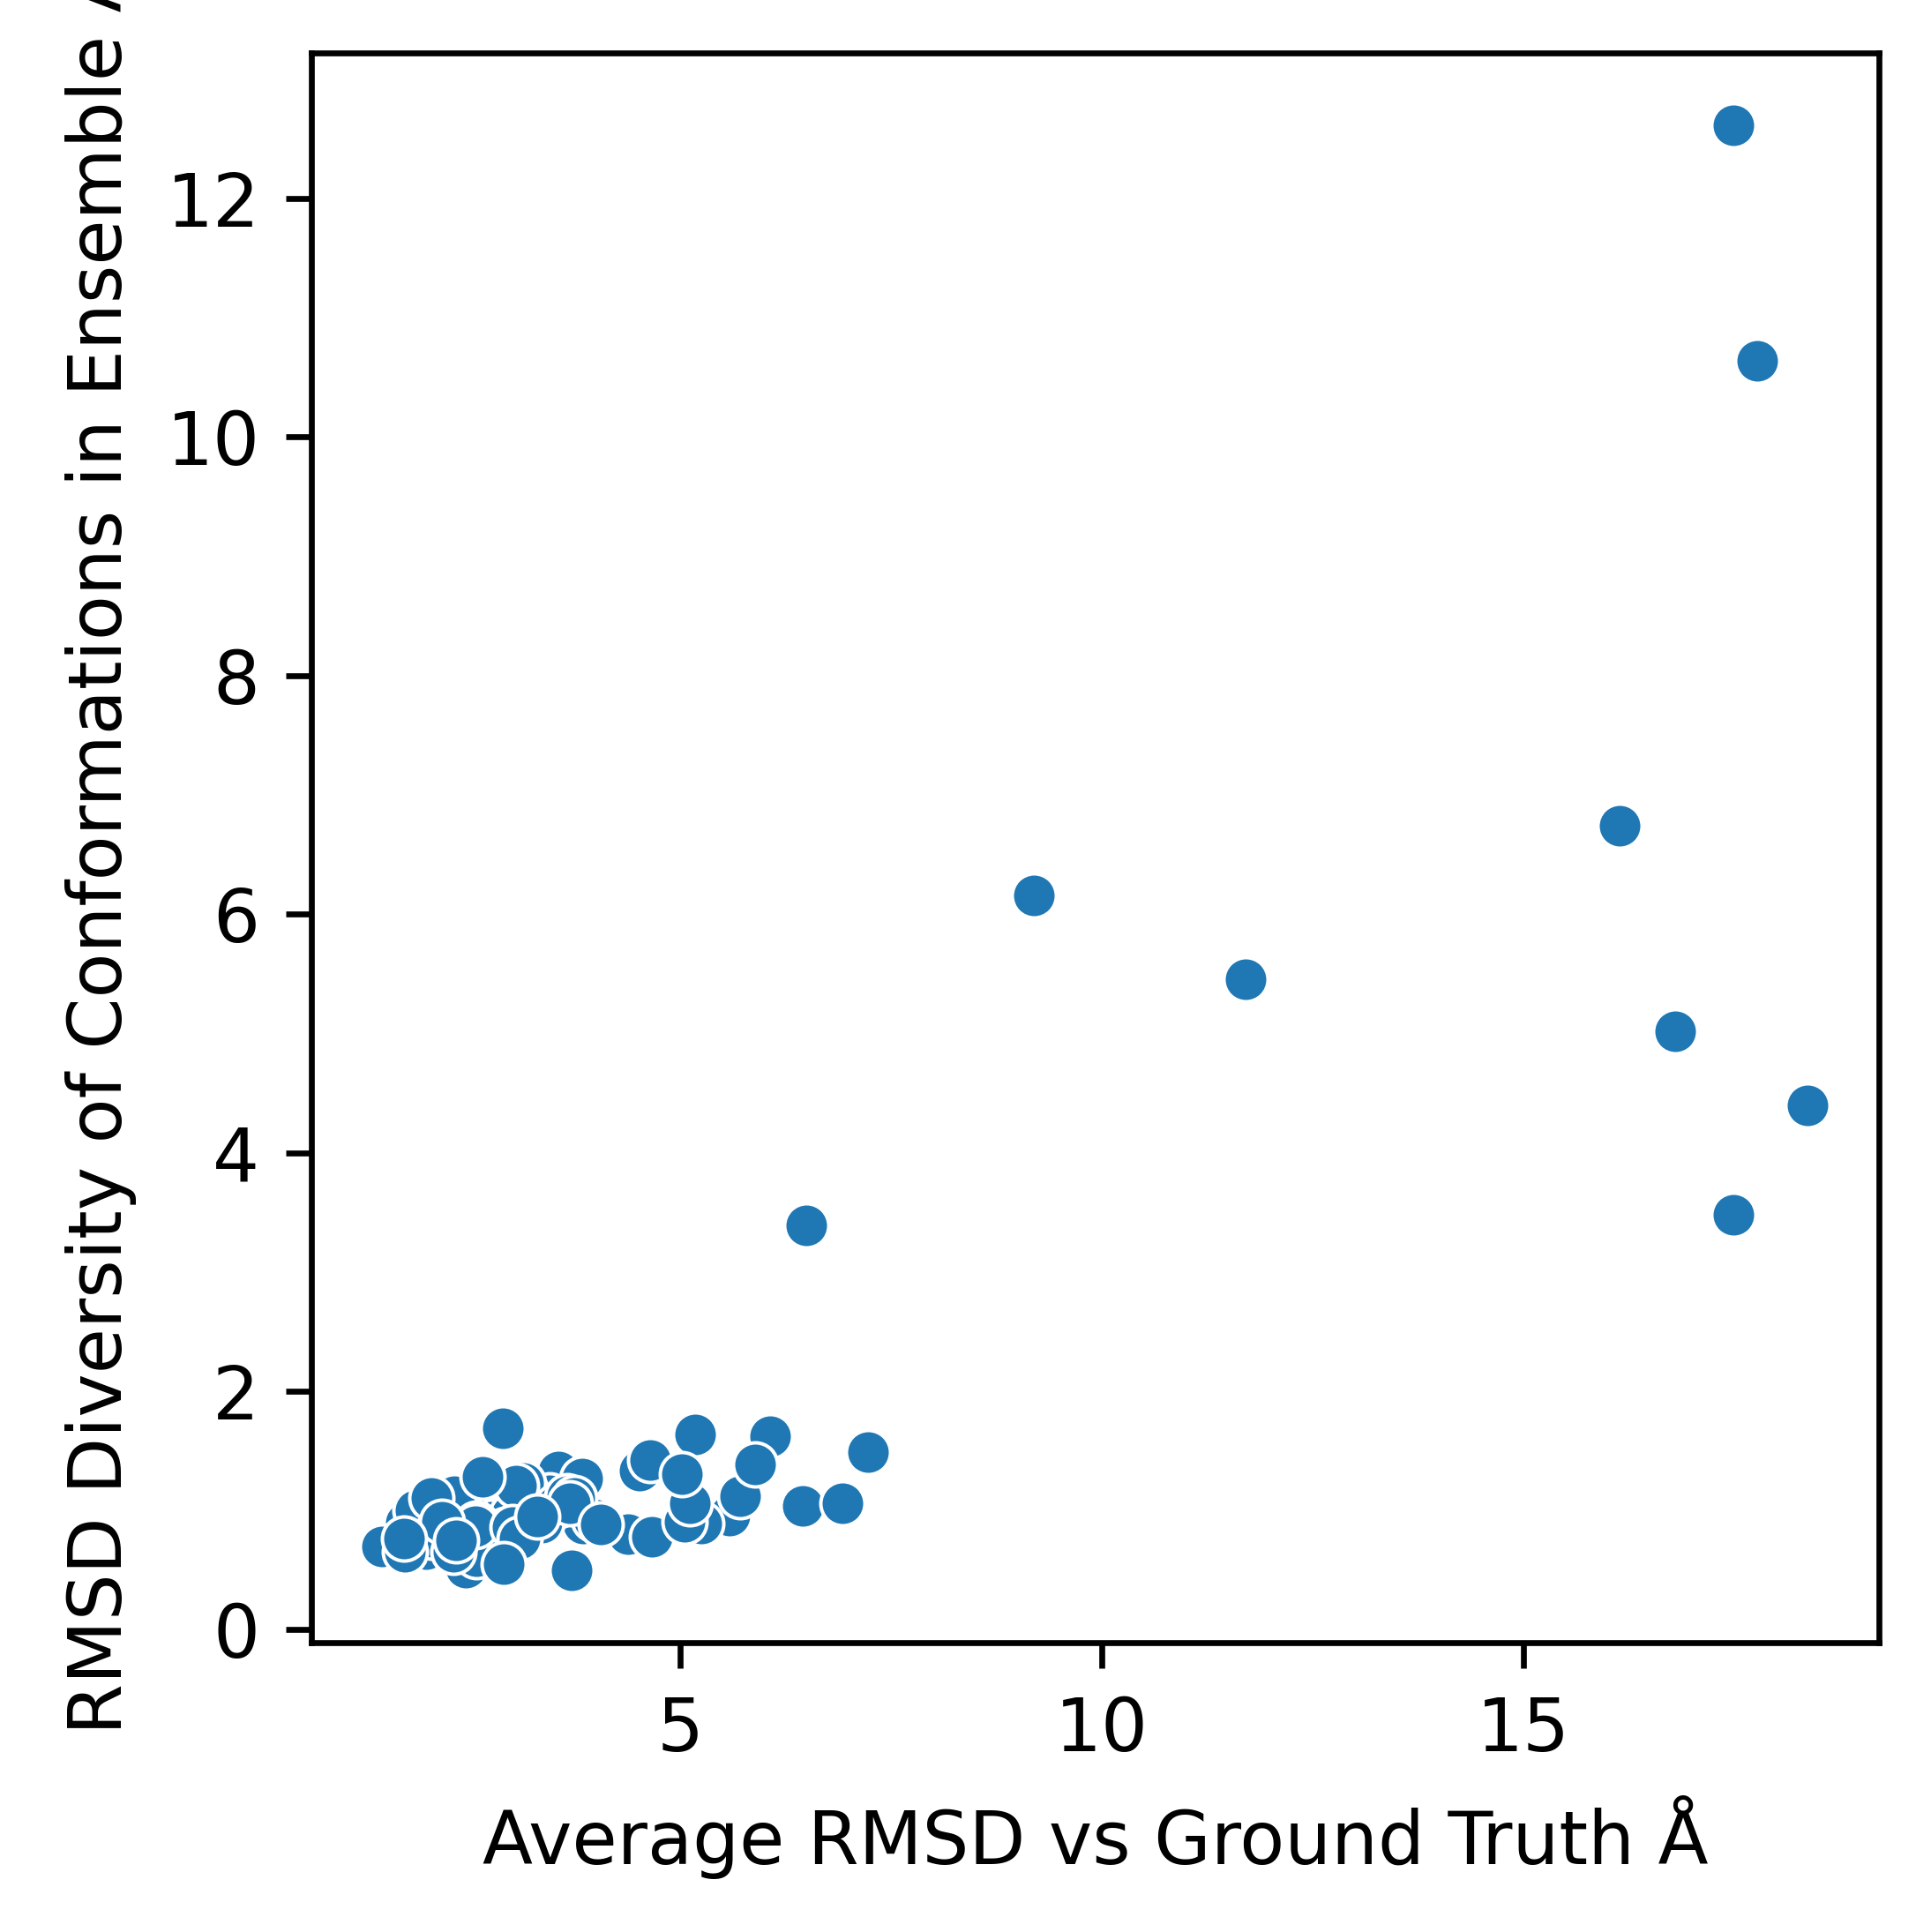

In [48]:
plt.figure(figsize=(3.75,3.75),dpi=600)
#sns.set_style('whitegrid')
ax = sns.scatterplot(data=plot_full, x='rmsd_avg',y='pair_rmsd_avg',palette='magma',legend=None)
plt.ylabel('RMSD Diversity of Conformations in Ensemble Å')
plt.xlabel('Average RMSD vs Ground Truth Å')
#plt.ylim(0,5.5)
plt.tight_layout()
#plt.legend(loc=2)
plt.savefig('Ensemble_deversity.png')